In [1]:
import mlflow
import mlflow.sklearn


In [2]:
import sys
print(sys.executable)

c:\Users\Student\Downloads\customerchurunprediction\venv\Scripts\python.exe


In [3]:
import mlflow
import mlflow.sklearn

print(mlflow.__version__)

3.14.0


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    sep="\t"
)

In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df = pd.get_dummies(df, drop_first=True)

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

c:\Users\Student\Downloads\customerchurunprediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [9]:
y_pred = lr.predict(X_test)

In [10]:
import mlflow
import mlflow.sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create experiment
mlflow.set_experiment("Customer Churn Prediction")

with mlflow.start_run():

    # Train model
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)

    # Predictions
    y_pred = lr.predict(X_test)
    y_prob = lr.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print metrics
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    # Log parameters
    mlflow.log_param("Model", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)

    # Log metrics
    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("F1 Score", f1)

    # Log model
    mlflow.sklearn.log_model(lr, "model")
    import joblib
import os

os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(lr, "../models/best_model.pkl")

# Save the feature names used during training
joblib.dump(X_train.columns.tolist(), "../models/model_columns.pkl")

print("Model and feature columns saved successfully!")

c:\Users\Student\Downloads\customerchurunprediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/07/13 12:35:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy : 0.8031272210376688
Precision: 0.6456456456456456
Recall   : 0.5748663101604278
F1 Score : 0.6082036775106082

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix
[[915 118]
 [159 215]]
Model and feature columns saved successfully!


In [11]:
import joblib

joblib.dump(model, "../models/best_model.pkl")

NameError: name 'model' is not defined

In [ ]:
import joblib

model = joblib.load("../models/best_model.pkl")

print(hasattr(model, "multi_class"))
print(model)

False
LogisticRegression(max_iter=1000)


In [ ]:
import joblib

model = joblib.load("../models/best_model.pkl")
print(model)
print(hasattr(model, "multi_class"))

LogisticRegression(max_iter=1000)
False


In [ ]:
joblib.dump(lr, "../models/best_model.pkl")
joblib.dump(X_train.columns.tolist(), "../models/model_columns.pkl")

['../models/model_columns.pkl']

In [ ]:
import pickle

with open("../models/best_model.pkl", "rb") as f:
    model = pickle.load(f)

print(hasattr(model, "multi_class"))
print(model)

UnpicklingError: STACK_GLOBAL requires str

In [ ]:
import joblib

model = joblib.load("../models/best_model.pkl")
print(model)

LogisticRegression(max_iter=1000)


In [ ]:
import sklearn
print(sklearn.__version__)

1.9.0


In [ ]:
import joblib

model = joblib.load("../models/best_model.pkl")
print(model)

LogisticRegression(max_iter=1000)


In [ ]:
import pickle

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(lr, f)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8031272210376688
Precision: 0.6456456456456456
Recall   : 0.5748663101604278
F1 Score : 0.6082036775106082


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[915, 118],
       [159, 215]])

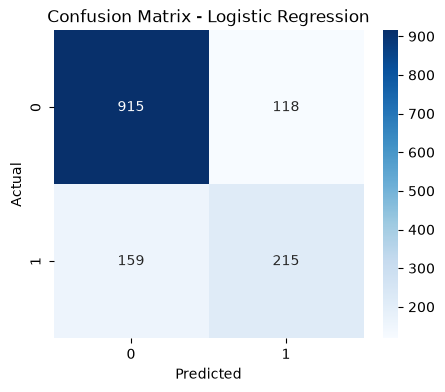

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# Logistic Regression Results

### Metrics

- Accuracy
- Precision
- Recall
- F1 Score

### Observation

Logistic Regression serves as a strong baseline model for binary classification. We will compare its performance with Decision Tree, Random Forest, and XGBoost to determine the best-performing model.

Decision Tree

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.7185501066098081
Precision: 0.4701086956521739
Recall   : 0.4625668449197861
F1 Score : 0.46630727762803237


Random Forest

In [ ]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.7896233120113717
Precision: 0.6258064516129033
Recall   : 0.5187165775401069
F1 Score : 0.5672514619883041


XGBoost

In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.7782515991471215
Precision: 0.5890804597701149
Recall   : 0.5481283422459893
F1 Score : 0.5678670360110804


Final Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803127,0.645646,0.574866,0.608204
3,XGBoost,0.778252,0.589080,0.548128,0.567867
2,Random Forest,0.789623,0.625806,0.518717,0.567251
1,Decision Tree,0.718550,0.470109,0.462567,0.466307


In [ ]:
import joblib

joblib.dump(X.columns.tolist(), "../models/model_columns.pkl")

['../models/model_columns.pkl']

In [ ]:
import joblib

joblib.dump(lr, "../models/best_model.pkl")
joblib.dump(X.columns.tolist(), "../models/model_columns.pkl")

['../models/model_columns.pkl']

In [ ]:
import pickle

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(lr, f)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import pickle

with open("../models/best_model.pkl", "rb") as f:
    model = pickle.load(f)

print(model)
print(type(model))
print(model.__dict__.keys())

LogisticRegression(max_iter=1000)
<class 'sklearn.linear_model._logistic.LogisticRegression'>
dict_keys(['penalty', 'C', 'l1_ratio', 'dual', 'tol', 'fit_intercept', 'intercept_scaling', 'class_weight', 'random_state', 'solver', 'max_iter', 'verbose', 'warm_start', 'n_jobs', 'feature_names_in_', 'n_features_in_', 'classes_', 'n_iter_', 'coef_', 'intercept_'])


In [ ]:
print("Scikit-learn version:")
import sklearn
print(sklearn.__version__)

print("\nHas multi_class?")
print(hasattr(model, "multi_class"))

print("\nValue:")
print(getattr(model, "multi_class", "NOT FOUND"))


Scikit-learn version:
1.9.0

Has multi_class?
False

Value:
NOT FOUND


In [ ]:
print(model.__dict__)

{'penalty': 'deprecated', 'C': 1.0, 'l1_ratio': 0.0, 'dual': False, 'tol': 0.0001, 'fit_intercept': True, 'intercept_scaling': 1, 'class_weight': None, 'random_state': None, 'solver': 'lbfgs', 'max_iter': 1000, 'verbose': 0, 'warm_start': False, 'n_jobs': None, 'feature_names_in_': array(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessB

In [ ]:
print(hasattr(model, "multi_class"))

False


In [ ]:
import joblib

model = joblib.load("../models/best_model.pkl")
print(model)

LogisticRegression(max_iter=1000)


In [ ]:
import joblib

model = joblib.load("../models/best_model.pkl")
print(model)

LogisticRegression(max_iter=1000)


In [ ]:
import joblib

model = joblib.load("../models/best_model.pkl")

print(model)
print(hasattr(model, "multi_class"))

if hasattr(model, "multi_class"):
    print(model.multi_class)

LogisticRegression(max_iter=1000)
False


In [ ]:
pip install scikit-learn==1.5.2


   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB 682.7 kB/s eta 0:00:17
   - -------------------------------------- 0.4/11.0 MB 4.9 MB/s eta 0:00:03
   ---- ----------------------------------- 1.1/11.0 MB 8.8 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/11.0 MB 11.6 MB/s eta 0:00:01
   --------- ------------------------------ 2.7/11.0 MB 14.6 MB/s eta 0:00:01
   ------------- -------------------------- 3.8/11.0 MB 15.2 MB/s eta 0:00:01
   ---------------- ----------------------- 4.7/11.0 MB 16.5 MB/s eta 0:00:01
   -------------------- ------------------- 5.7/11.0 MB 17.4 MB/s eta 0:00:01
   ------------------------ --------------- 6.6/11.0 MB 17.6 MB/s eta 0:00:01
   --------------------------- ------------ 7.7/11.0 MB 18.8 MB/s eta 0:00:01
   ------------------------------- -------- 8.6/11.0 MB 18.9 MB/s eta 0:00:01
   ----------------------------------- ---- 9.7/11.0 MB 19.3 MB/s eta 0:0

  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sklearn
print(sklearn.__version__)

1.9.0


In [ ]:
import sys
print(sys.executable)

c:\Users\Student\Downloads\customerchurunprediction\venv\Scripts\python.exe


In [ ]:
import sklearn
print(sklearn.__version__)
print(sklearn.__file__)

1.5.2
c:\Users\Student\Downloads\customerchurunprediction\venv\Lib\site-packages\sklearn\__init__.py


In [12]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(lr, "../models/best_model.pkl")
joblib.dump(X_train.columns.tolist(), "../models/model_columns.pkl")

print("Model saved successfully!")

Model saved successfully!


In [13]:
import joblib
import sklearn

print(sklearn.__version__)

model = joblib.load("../models/best_model.pkl")
print(model)

1.5.2
LogisticRegression(max_iter=1000)
